<a href="https://colab.research.google.com/github/nomanabdullah04/Natural-Language-Processing-NLP-/blob/main/TF_IFD_in_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# : TF-IDF in Natural Language Processing (NLP)

**TF-IDF** stands for **Term Frequency - Inverse Document Frequency**. It is a numerical statistic that reflects how important a word is to a document in a collection or corpus.

It is widely used in NLP for:
* Information retrieval
* Document classification
* Text summarization
* Feature extraction before feeding text into machine learning models

## 1. Our Corpus (Dataset) Setup

Let's consider three sample sentences (documents) for our analysis:
* **S1:** "good boy"
* **S2:** "good girl"
* **S3:** "boy girl good"

**Unique Vocabulary List:** `['good', 'boy', 'girl']`  
**Total Number of Sentences ($N$):** $3$

## 2. Step One: Term Frequency (TF)

### **Definition**
Term Frequency measures how frequently a term occurs in a particular document. Since documents can be of different lengths, a term may appear much more often in long documents than short ones. To normalize this, we divide by the total number of words in that document.

### **Formula**
$$\text{TF} = \frac{\text{Number of repetitions of the word in a sentence}}{\text{Total number of words in that sentence}}$$

### **Calculation Breakdown:**
* **Sentence 1 ($S_1$: "good boy")** — Total words = $2$
  * $\text{TF}(\text{"good"}) = \frac{1}{2} = 0.5$
  * $\text{TF}(\text{"boy"}) = \frac{1}{2} = 0.5$
  * $\text{TF}(\text{"girl"}) = \frac{0}{2} = 0$

* **Sentence 2 ($S_2$: "good girl")** — Total words = $2$
  * $\text{TF}(\text{"good"}) = \frac{1}{2} = 0.5$
  * $\text{TF}(\text{"boy"}) = \frac{0}{2} = 0$
  * $\text{TF}(\text{"girl"}) = \frac{1}{2} = 0.5$

* **Sentence 3 ($S_3$: "boy girl good")** — Total words = $3$
  * $\text{TF}(\text{"good"}) = \frac{1}{3} \approx 0.333$
  * $\text{TF}(\text{"boy"}) = \frac{1}{3} \approx 0.333$
  * $\text{TF}(\text{"girl"}) = \frac{1}{3} \approx 0.333$

## 3. Step Two: Inverse Document Frequency (IDF)

### **Definition**
While Term Frequency gives equal weight to all words, certain words like "is", "the", or "of" appear very frequently across *all* documents and carry very little informational value. Inverse Document Frequency diminishes the weight of terms that occur very frequently in the document set and increases the weight of terms that occur rarely.

### **Formula**
$$\text{IDF} = \log_e \left( \frac{\text{Total Number of Sentences}}{\text{Number of sentences containing the word}} \right)$$

### **Calculation Breakdown:**
* **Word "good":** Appears in $S_1, S_2, S_3$ (Total $3$ sentences)
  $$\text{IDF}(\text{"good"}) = \log_e \left(\frac{3}{3}\right) = \log_e(1) = 0$$

* **Word "boy":** Appears in $S_1, S_3$ (Total $2$ sentences)
  $$\text{IDF}(\text{"boy"}) = \log_e \left(\frac{3}{2}\right) \approx 0.405$$

* **Word "girl":** Appears in $S_2, S_3$ (Total $2$ sentences)
  $$\text{IDF}(\text{"girl"}) = \log_e \left(\frac{3}{2}\right) \approx 0.405$$

## 4. Step Three: Final TF-IDF Score

### **Definition**
The final TF-IDF score for a word in a specific document is calculated by multiplying its Term Frequency by its Inverse Document Frequency.

$$\text{TF-IDF} = \text{TF} \times \text{IDF}$$

* High weights are reached by term-document pairs with a high term frequency (in the given document) and a low document frequency of the term in the whole collection.

### **Final Matrix Insights:**
* **Word "good"** ends up with a score of `0` across all sentences because its IDF is `0` (it appears everywhere, making it non-informative).
* Rare words or words exclusive to fewer sentences receive higher combined values, highlighting their descriptive importance for those specific sentences.
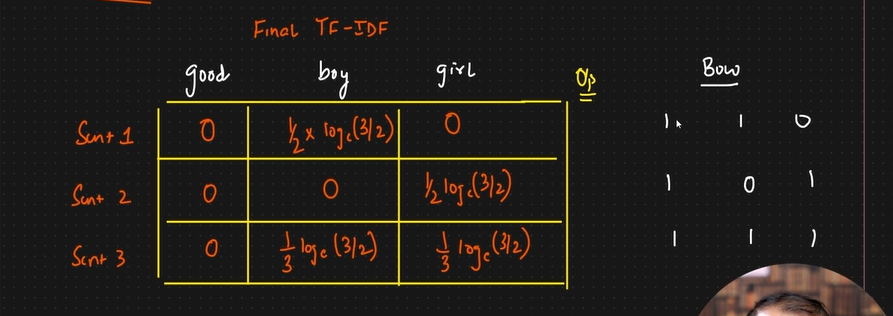

## 5. Advantages and Disadvantages of TF-IDF

### **Advantages**
* **Simplicity and Intuitiveness:** It is straightforward to calculate and easy to understand mathematically.
* **Highlights Important Words:** It effectively filters out common, less-informative words (like "the", "is", etc., if present in the corpus) while boosting the weight of unique or rare keywords that define a document's core topic.
* **Unsupervised Learning:** It does not require any prior training or labeling of text data.
* **Fast Computation:** Vectorizing text using TF-IDF is computationally efficient and fast, even for large datasets.

### **Disadvantages**
* **Lack of Semantic Understanding:** TF-IDF treats words independently and relies strictly on exact keyword matches. It fails to capture synonyms, context, or semantic meaning (e.g., "happy" and "joyful" are treated as completely unrelated dimensions).
* **Out-of-Vocabulary Problem:** It cannot compute scores for new words that were not present in the initial training vocabulary/corpus.
* **Sparsity:** As the vocabulary size grows, the resulting TF-IDF matrices become extremely large and sparse (mostly filled with zeros), which can consume high memory.
* **No Word Order Consideration:** It is based on a "bag-of-words" model, meaning the sequential order and grammar of words in a sentence are completely ignored.

In [42]:
import pandas as pd
message=pd.read_csv('/content/SMSSpamCollection', sep='\t', header=None, encoding='latin-1')
message.columns=['label','message']

In [43]:
message.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [44]:
#Apply snowdown stemmming technique
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import re
stemmer=SnowballStemmer('english')
corpus=[]



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [45]:
for i in range(0,len(message)):
  review=re.sub('[^a-zA-Z]',' ',message['message'][i])
  review=review.lower()
  review=review.split()
  review=[stemmer.stem(word) for word in review if not word in stopwords.words('english')]
  review=' '.join(review)
  corpus.append(review)


In [46]:
review

'rofl true name'

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
cv=TfidfVectorizer(max_features=2500,ngram_range=(2,2))
X=cv.fit_transform(corpus).toarray()


In [48]:
cv.vocabulary_

{'ok lar': np.int64(1426),
 'free entri': np.int64(626),
 'entri wkli': np.int64(552),
 'wkli comp': np.int64(2412),
 'cup final': np.int64(403),
 'std txt': np.int64(1940),
 'txt rate': np.int64(2175),
 'rate appli': np.int64(1694),
 'freemsg hey': np.int64(647),
 'like fun': np.int64(1086),
 'per request': np.int64(1482),
 'request mell': np.int64(1750),
 'mell mell': np.int64(1225),
 'mell oru': np.int64(1226),
 'oru minnaminungint': np.int64(1459),
 'minnaminungint nurungu': np.int64(1256),
 'nurungu vettam': np.int64(1405),
 'vettam set': np.int64(2271),
 'set callertun': np.int64(1841),
 'callertun caller': np.int64(239),
 'caller press': np.int64(237),
 'press copi': np.int64(1655),
 'copi friend': np.int64(372),
 'friend callertun': np.int64(650),
 'winner valu': np.int64(2400),
 'valu network': np.int64(2268),
 'network custom': np.int64(1358),
 'claim call': np.int64(293),
 'call claim': np.int64(192),
 'claim code': np.int64(294),
 'valid hour': np.int64(2265),
 'entitl upda

In [49]:
import numpy as np

np.set_printoptions(edgeitems=30,linewidth=100000,formatter=dict(float=lambda x: "%.3g" %x))

In [50]:
X

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0